In [1]:
# load命令重新加载tokenizer模块
%load_ext autoreload
%autoreload 2

In [2]:
# 加载src/tokenizer.py
import sys
sys.path.append('./src')

from tokenizer import SimpleTokenizer
import torch

In [3]:
tokenizer = SimpleTokenizer()

text = "His wife glanced at him deprecatingly, but his eyes travelled past her to the portrait."
tokenizer.encode(text)

[51,
 1103,
 493,
 180,
 546,
 328,
 5,
 239,
 549,
 417,
 1029,
 759,
 539,
 1016,
 988,
 782,
 7]

In [4]:
tokenizer.encode(text)

[51,
 1103,
 493,
 180,
 546,
 328,
 5,
 239,
 549,
 417,
 1029,
 759,
 539,
 1016,
 988,
 782,
 7]

In [5]:
vocab_size = len(tokenizer)
vocab_size

1132

In [6]:
emb_layer = torch.nn.Embedding(vocab_size, 8)
emb_layer.weight

Parameter containing:
tensor([[ 0.4006, -0.2017,  0.8934,  ..., -1.2720,  2.0640,  0.2809],
        [ 1.8080, -0.5629,  0.0121,  ..., -0.2570,  1.7716,  0.4820],
        [-1.7032,  1.2985, -0.8339,  ...,  0.6377, -0.1619, -0.2196],
        ...,
        [-0.6473, -0.4889, -0.1604,  ...,  1.1180, -0.4677,  1.0947],
        [ 0.1404,  0.8121,  0.2248,  ...,  1.4223,  0.7742, -0.3260],
        [-0.3216, -0.4461,  0.8048,  ...,  1.3734,  0.5636,  0.0914]],
       requires_grad=True)

In [7]:
emb_layer(torch.tensor(tokenizer.encode(text)))

tensor([[ 8.1936e-02, -8.0778e-01,  5.8744e-01, -1.1757e+00,  1.6015e-01,
          2.0991e-02, -3.2007e-01,  1.6509e+00],
        [-4.4853e-01,  7.1912e-01,  5.9478e-01,  6.2921e-02,  8.1632e-01,
          1.3640e+00, -2.7945e-01,  1.6259e-01],
        [ 6.2050e-01,  3.1776e-01,  2.9972e-01,  5.4826e-01, -4.2915e-01,
          4.0779e-01, -1.3347e+00, -9.1761e-02],
        [ 1.0186e+00, -2.9306e-01,  1.0777e+00, -6.0481e-01,  2.1194e-02,
         -8.1844e-01, -1.6241e+00, -1.1230e+00],
        [-7.6939e-01, -9.1978e-01, -2.1604e-01, -7.4682e-01, -5.2590e-01,
          7.8474e-01, -1.8628e+00, -8.3915e-01],
        [-1.4600e+00, -6.5582e-01,  7.0650e-01, -4.0813e-01, -1.0284e+00,
          1.2600e+00,  4.9262e-01, -1.3135e+00],
        [-6.7766e-01, -4.2749e-01,  8.0530e-01,  1.2440e-01, -1.5004e+00,
          4.8621e-01, -6.6435e-01, -2.8313e-01],
        [-2.3568e+00,  1.9874e+00, -6.6445e-01, -2.3308e-01,  6.2295e-01,
         -8.3910e-01,  1.7384e-01, -1.6680e-01],
        [ 4.3379

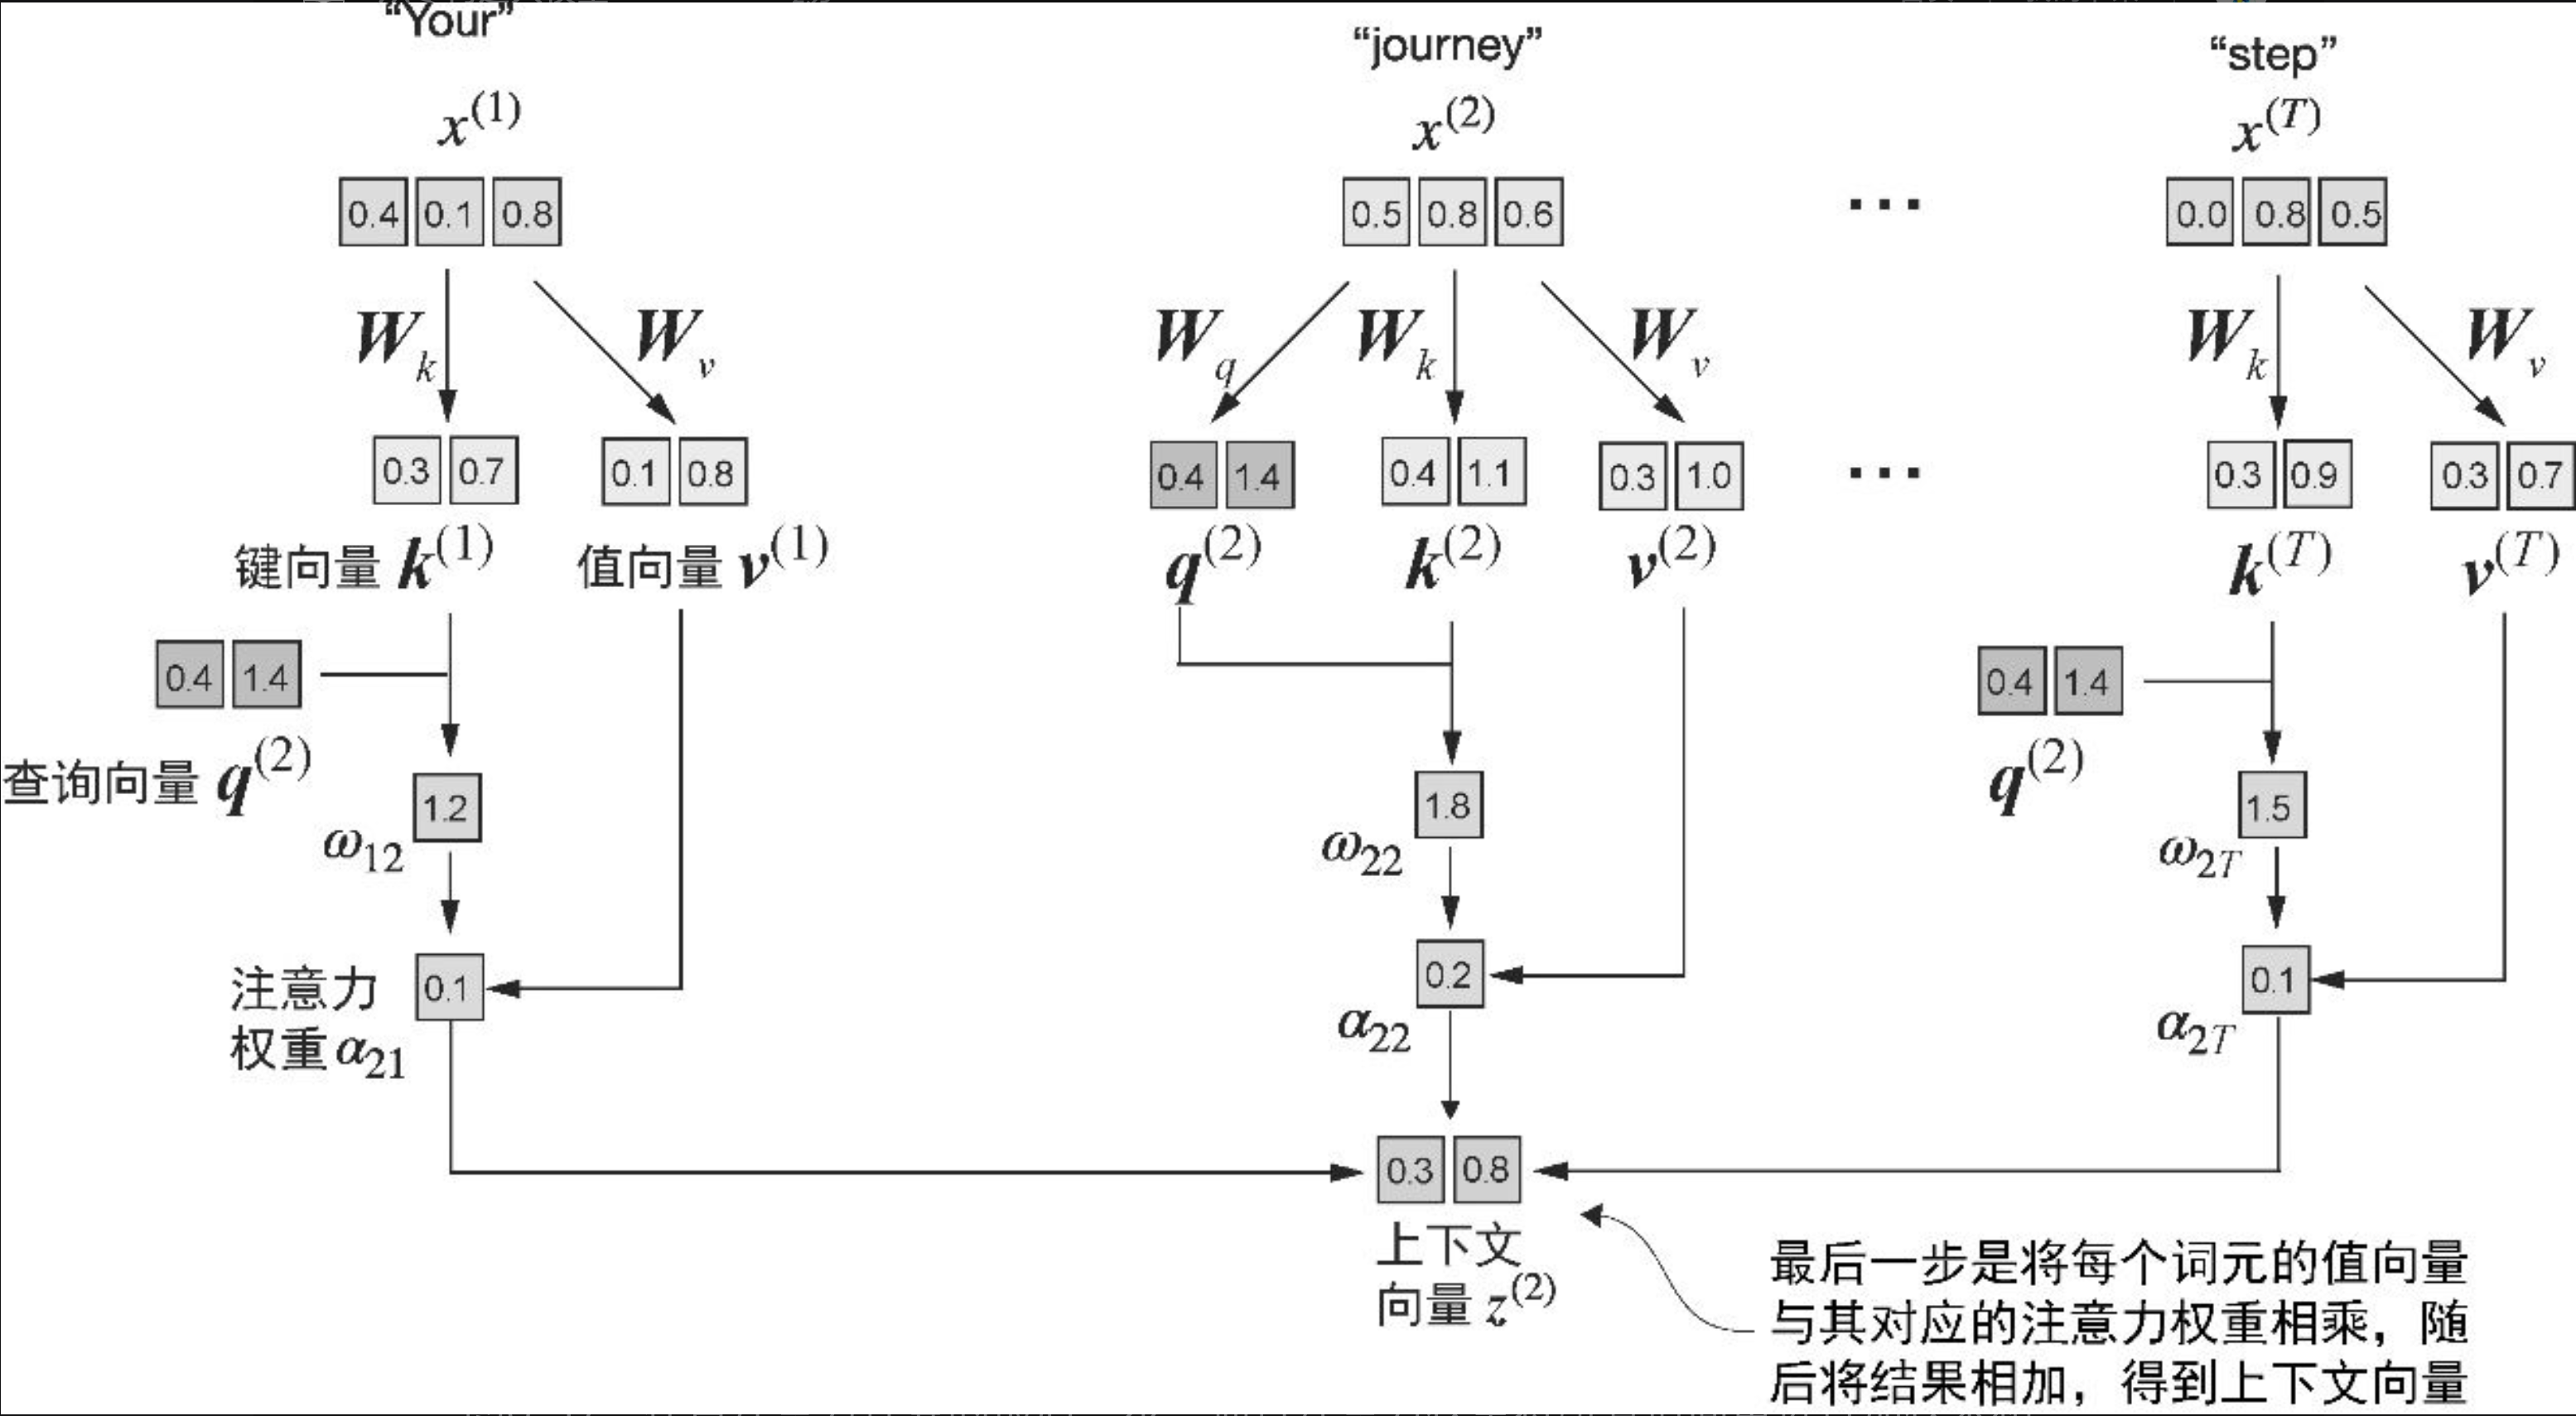

## 1. 缩放点积注意力
**缩放点积注意力**的原理对嵌入维度进行归一化是为了避免梯度过小，从而提升训练性能。例如，在类GPT大语言模型中，嵌入维度通常大于1000，这可能导致点积非常大，从而在反向传播时由于softmax函数的作用导致梯度非常小。当点积增大时，softmax函数会表现得更像阶跃函数，导致梯度接近零。这些小梯度可能会显著减慢学习速度或使训练停滞。因此，通过嵌入维度的平方根进行缩放解释了为什么这种自注意力机制也被称为缩放点积注意力机制。

设定$d_k=16$，缩放系数 $\sqrt{d_k}=4$
原始注意力分数：$[8, 4, 2]$

**① 不缩放**
$$\color{blue}[8, 4, 2]\rightarrow Softmax(·) \rightarrow [0.98, 0.02, 0.00]$$
- 分数过大
- Softmax 极度尖锐
- 几乎只关注第一个位置
- 梯度消失，难以训练

**② 缩放（除以$\sqrt{d_k}=4$）**
$$\color{blue}[8, 4, 2]\rightarrow ÷ 4\rightarrow [2, 1, 0.5]\rightarrow Softmax(·)\rightarrow[0.63, 0.23, 0.14]$$
- 分数回到合理范围
- Softmax 分布平滑
- 能关注多个相关位置
- 梯度正常，训练稳定

In [9]:
class SimpleSelfAttention(torch.nn.Module):
    """
    缩放点积注意力scaled dot-product attention
    """
    def __init__(self, d_in, d_out, bias = False):
        super().__init__()
        self.qw = torch.nn.Linear(d_in, d_out, bias=bias)
        self.kw = torch.nn.Linear(d_in, d_out, bias=bias)
        self.vw = torch.nn.Linear(d_in, d_out, bias=bias)
    

    def forward(self, x):
        q = self.qw(x)
        k = self.kw(x)
        v = self.vw(x)

        weight = torch.matmul(q, k.transpose(-2, -1))
        weight = weight / (d_out ** 0.5)
        weight = torch.softmax(weight, dim=-1)
        output = torch.matmul(weight, v)
        return output

## 2. 利用因果注意力隐藏未来信息